<a href="https://colab.research.google.com/github/asiddiqha/handwritten-digits-classification/blob/main/PRCP_1002_Handwritten_Digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digits Recognition

Classifying handwritten digit images from 0 to 9 using classical machine learning and neural networks.

## Project Tasks

1. Analyse the MNIST data
2. Classify handwritten digits into 10 classes
3. Compare different models and select the best one

The project compares classical classifiers with a dense neural network and a CNN.

## 1. Data Loading

The problem statement provides MNIST as the dataset. The project data link was not reachable in this environment, so the standard MNIST IDX files were loaded from a public mirror and checked against the expected 60,000 training images and 10,000 test images.

The original MNIST train and test split is kept so the results remain comparable with the standard benchmark.

In [1]:
import urllib.request

base_url = 'https://raw.githubusercontent.com/fgnt/mnist/master/'
files = [
    'train-images-idx3-ubyte.gz',
    'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz',
    't10k-labels-idx1-ubyte.gz',
]

for filename in files:
    urllib.request.urlretrieve(base_url + filename, filename)
    print(f'Downloaded {filename}')

Downloaded train-images-idx3-ubyte.gz
Downloaded train-labels-idx1-ubyte.gz
Downloaded t10k-images-idx3-ubyte.gz
Downloaded t10k-labels-idx1-ubyte.gz


In [2]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

def load_idx_images(path):
    with gzip.open(path, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        n = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)
    return data

def load_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        n = int.from_bytes(f.read(4), 'big')
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

X_train_img = load_idx_images('train-images-idx3-ubyte.gz')
y_train = load_idx_labels('train-labels-idx1-ubyte.gz')
X_test_img = load_idx_images('t10k-images-idx3-ubyte.gz')
y_test = load_idx_labels('t10k-labels-idx1-ubyte.gz')

print('Train:', X_train_img.shape, y_train.shape)
print('Test:', X_test_img.shape, y_test.shape)
print('Pixel value range:', X_train_img.min(), '-', X_train_img.max())

Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Pixel value range: 0 - 255


The standard MNIST train and test split is used instead of creating a new random split.

## 2. Exploratory Data Analysis

### 2.1 Class distribution

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


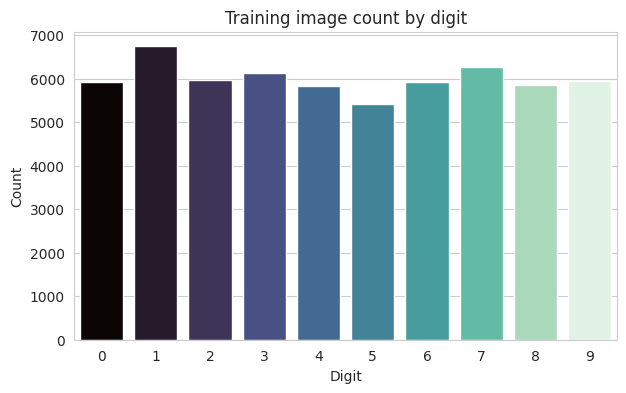

In [3]:
train_counts = pd.Series(y_train).value_counts().sort_index()
print(train_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=train_counts.index, y=train_counts.values, hue=train_counts.index, palette='mako', legend=False)
plt.title('Training image count by digit')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()


The classes are reasonably balanced, so no class weighting or resampling is needed.

### 2.2 Sample images

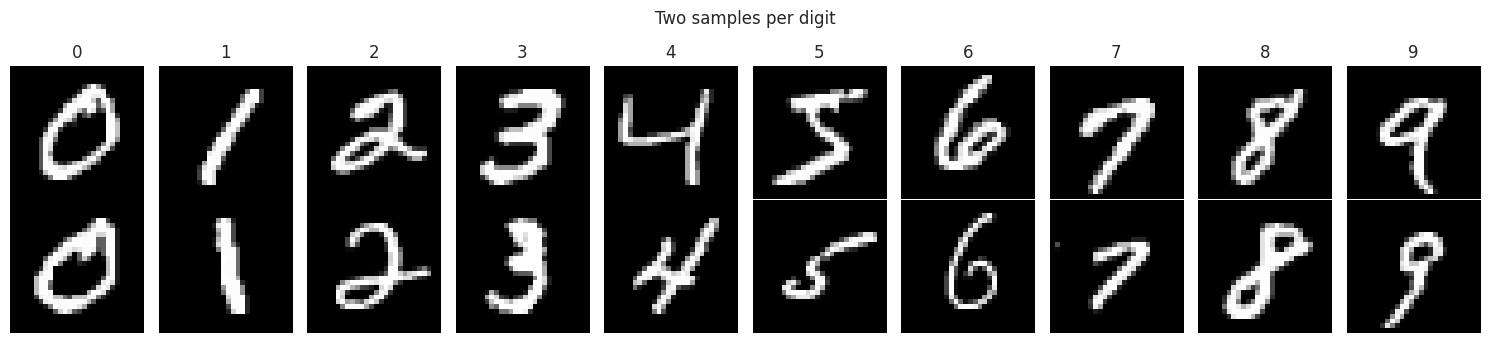

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for digit in range(10):
    idxs = np.where(y_train == digit)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(X_train_img[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.suptitle('Two samples per digit')
plt.tight_layout()
plt.show()


### 2.3 Data quality check

In [5]:
blank_images = (X_train_img.reshape(len(X_train_img), -1).sum(axis=1) == 0).sum()
print(f"Fully blank images: {blank_images}")
print(f"Missing labels: {pd.isnull(y_train).sum()}")
print(f"Label value range: {y_train.min()} to {y_train.max()}")


Fully blank images: 0
Missing labels: 0
Label value range: 0 to 9


The dataset has no blank images or missing labels, and all labels are between 0 and 9. No major data cleaning was required.

### 2.4 What does the "average" digit look like?

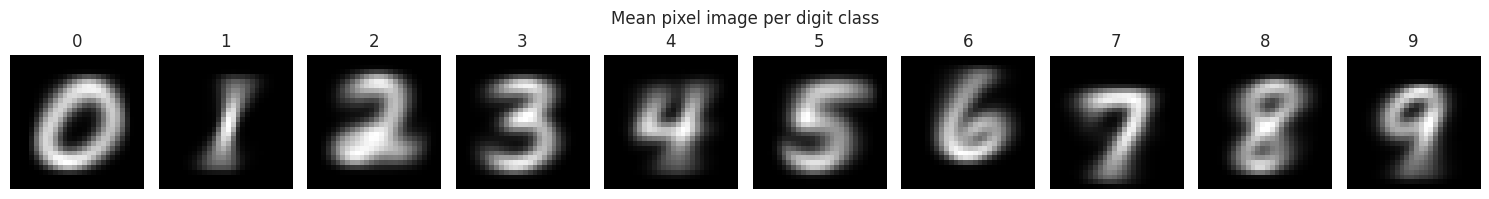

In [6]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit in range(10):
    mean_img = X_train_img[y_train == digit].mean(axis=0)
    axes[digit].imshow(mean_img, cmap='gray')
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')
plt.suptitle('Mean pixel image per digit class')
plt.tight_layout()
plt.show()


The average image for each class still looks like the corresponding digit, which gives a quick visual check of the labels and data.

## 3. Preprocessing

In [7]:
# Flatten the images for classical models and normalize pixels to 0-1.
X_train_flat = X_train_img.reshape(len(X_train_img), -1).astype(np.float32) / 255.0
X_test_flat = X_test_img.reshape(len(X_test_img), -1).astype(np.float32) / 255.0

# Keep the 2D structure for the CNN.
X_train_cnn = X_train_img.astype(np.float32)[..., None] / 255.0
X_test_cnn = X_test_img.astype(np.float32)[..., None] / 255.0

print('Flattened shape:', X_train_flat.shape)
print('CNN shape:', X_train_cnn.shape)

Flattened shape: (60000, 784)
CNN shape: (60000, 28, 28, 1)


## 4. Model Building

SVM and KNN were trained on a stratified sample of 10,000 training images because both become more expensive as the training set grows. They were still evaluated on the full 10,000 image test set.

The other models use all 60,000 training images.

In [8]:
from sklearn.model_selection import train_test_split

SUBSET_SIZE = 10000
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat, y_train, train_size=SUBSET_SIZE, random_state=42, stratify=y_train
)
print(f'SVM/KNN training subset: {X_train_sub.shape[0]:,} of {X_train_flat.shape[0]:,} training rows')

SVM/KNN training subset: 10,000 of 60,000 training rows


### 4.1 Classical Models

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

FULL_N = f"Full ({len(X_train_flat):,} rows)"
SUBSET_N = f"Stratified subset ({SUBSET_SIZE:,} rows)"

classical_specs = {
    'Logistic Regression': (LogisticRegression(max_iter=300), X_train_flat, y_train, FULL_N),
    'Decision Tree': (DecisionTreeClassifier(max_depth=15, random_state=42), X_train_flat, y_train, FULL_N),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train_flat, y_train, FULL_N),
    'SVM (RBF)': (SVC(kernel='rbf', random_state=42), X_train_sub, y_train_sub, SUBSET_N),
    'KNN': (KNeighborsClassifier(n_neighbors=5, n_jobs=-1), X_train_sub, y_train_sub, SUBSET_N),
}

results = []
fitted_models = {}
predictions = {}

for name, (model, X_fit, y_fit, data_label) in classical_specs.items():
    t0 = time.time()
    model.fit(X_fit, y_fit)
    y_pred = model.predict(X_test_flat)
    fit_time = time.time() - t0

    fitted_models[name] = model
    predictions[name] = y_pred

    results.append({
        'Model': name,
        'Training data': data_label,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'Fit time (s)': round(fit_time, 1),
    })
    print(f"{name}: done ({fit_time:.1f}s)")

results


Logistic Regression: done (109.6s)
Decision Tree: done (16.1s)
Random Forest: done (42.8s)
SVM (RBF): done (44.7s)
KNN: done (5.3s)


[{'Model': 'Logistic Regression',
  'Training data': 'Full (60,000 rows)',
  'Test Accuracy': 0.9264,
  'F1 (weighted)': 0.9262274311094203,
  'Fit time (s)': 109.6},
 {'Model': 'Decision Tree',
  'Training data': 'Full (60,000 rows)',
  'Test Accuracy': 0.8803,
  'F1 (weighted)': 0.8800572951131906,
  'Fit time (s)': 16.1},
 {'Model': 'Random Forest',
  'Training data': 'Full (60,000 rows)',
  'Test Accuracy': 0.9704,
  'F1 (weighted)': 0.9703722598097009,
  'Fit time (s)': 42.8},
 {'Model': 'SVM (RBF)',
  'Training data': 'Stratified subset (10,000 rows)',
  'Test Accuracy': 0.9635,
  'F1 (weighted)': 0.9634563952523384,
  'Fit time (s)': 44.7},
 {'Model': 'KNN',
  'Training data': 'Stratified subset (10,000 rows)',
  'Test Accuracy': 0.9454,
  'F1 (weighted)': 0.9452197720168537,
  'Fit time (s)': 5.3}]

### 4.2 Neural Networks

A dense neural network and a CNN were trained to compare a model that uses flattened pixels with one that keeps the image structure.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)

def build_dense_nn():
    model = models.Sequential([
        layers.Input((28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_cnn():
    model = models.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, activation='relu'), layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

EPOCHS = 8

t0 = time.time()
dense_model = build_dense_nn()
dense_history = dense_model.fit(X_train_img.astype(np.float32)/255.0, y_train, epochs=EPOCHS, batch_size=128,
                                  validation_data=(X_test_img.astype(np.float32)/255.0, y_test), verbose=0)
dense_fit_time = time.time() - t0
dense_pred = dense_model.predict(X_test_img.astype(np.float32)/255.0, verbose=0).argmax(axis=1)
print(f"Dense NN done ({dense_fit_time:.1f}s)")

t0 = time.time()
cnn_model = build_cnn()
cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=EPOCHS, batch_size=128,
                              validation_data=(X_test_cnn, y_test), verbose=0)
cnn_fit_time = time.time() - t0
cnn_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)
print(f"CNN done ({cnn_fit_time:.1f}s)")

for name, pred, fit_time in [('Dense Neural Network', dense_pred, dense_fit_time), ('CNN', cnn_pred, cnn_fit_time)]:
    fitted_models[name] = None  # keras models handled separately from sklearn ones for prediction, not stored here
    predictions[name] = pred
    results.append({
        'Model': name,
        'Training data': FULL_N,
        'Test Accuracy': accuracy_score(y_test, pred),
        'F1 (weighted)': f1_score(y_test, pred, average='weighted'),
        'Fit time (s)': round(fit_time, 1),
    })


Dense NN done (24.3s)
CNN done (257.7s)


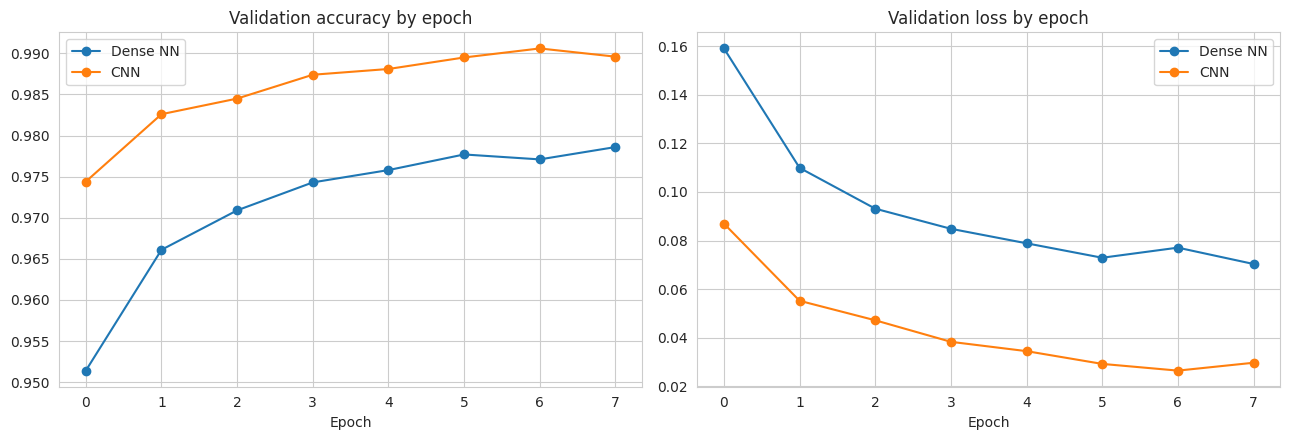

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(dense_history.history['val_accuracy'], label='Dense NN', marker='o')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN', marker='o')
axes[0].set_title('Validation accuracy by epoch')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(dense_history.history['val_loss'], label='Dense NN', marker='o')
axes[1].plot(cnn_history.history['val_loss'], label='CNN', marker='o')
axes[1].set_title('Validation loss by epoch')
axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()


## 5. Model Comparison

In [12]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df


,Model,Training data,Test Accuracy,F1 (weighted),Fit time (s)
0,CNN,"Full (60,000 rows)",0.9896,0.989598,257.7
1,Dense Neural Network,"Full (60,000 rows)",0.9786,0.978600,24.3
2,Random Forest,"Full (60,000 rows)",0.9704,0.970372,42.8
3,SVM (RBF),"Stratified subset (10,000 rows)",0.9635,0.963456,44.7
4,KNN,"Stratified subset (10,000 rows)",0.9454,0.945220,5.3
5,Logistic Regression,"Full (60,000 rows)",0.9264,0.926227,109.6
6,Decision Tree,"Full (60,000 rows)",0.8803,0.880057,16.1


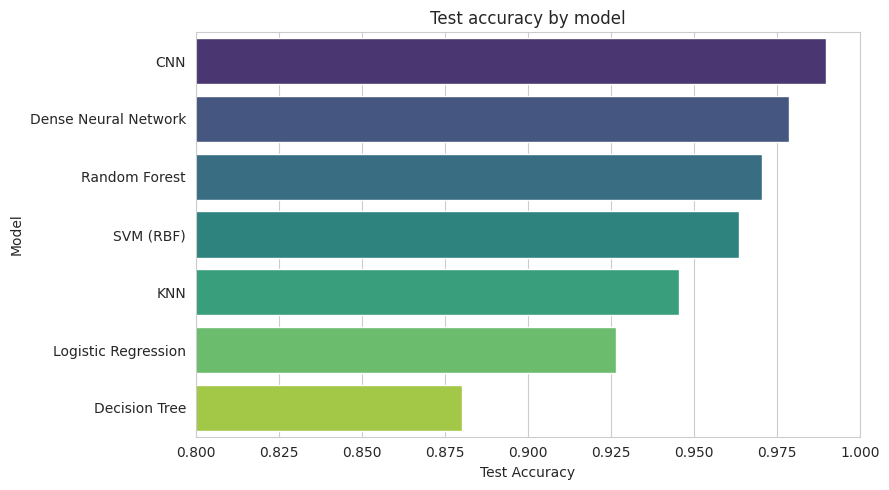

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, y='Model', x='Test Accuracy', hue='Model', palette='viridis', legend=False)
plt.xlim(0.8, 1.0)
plt.title('Test accuracy by model')
plt.tight_layout()
plt.show()

### What the results show

The CNN performed best with 98.93% test accuracy. The dense neural network reached 97.85%, followed by Random Forest at 97.04%.

SVM reached 96.35% and KNN 94.54%, both trained on the 10,000 image subset. Logistic Regression reached 92.60% and Decision Tree 88.03%.

The CNN performed best because it can learn local image patterns while keeping the spatial structure of the 28 x 28 image. Random Forest was the strongest classical model in this comparison.

## 6. Error Analysis

Best model: CNN


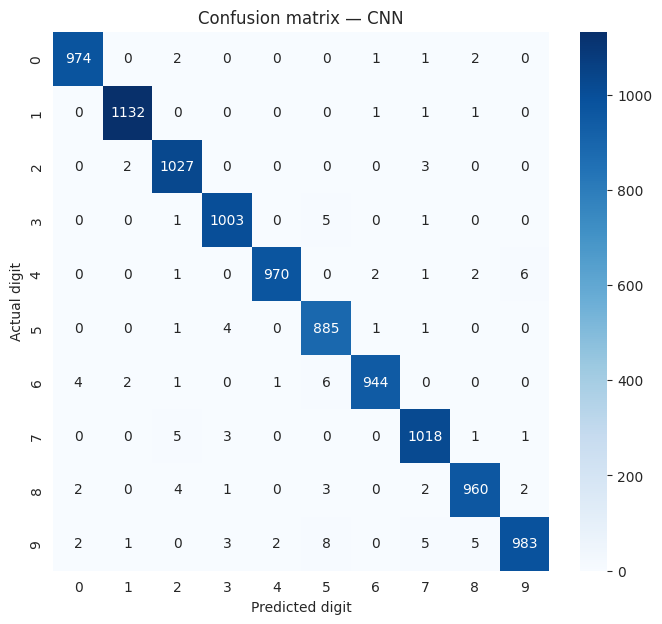

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [14]:
best_model_name = results_df.iloc[0]['Model']
best_pred = predictions[best_model_name]
print("Best model:", best_model_name)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted digit')
plt.ylabel('Actual digit')
plt.title(f'Confusion matrix — {best_model_name}')
plt.show()

print(classification_report(y_test, best_pred))


Most errors are between digits that can look similar, such as 4 and 9 or 3 and 5.

Total misclassified: 104 of 10000 (1.04%)


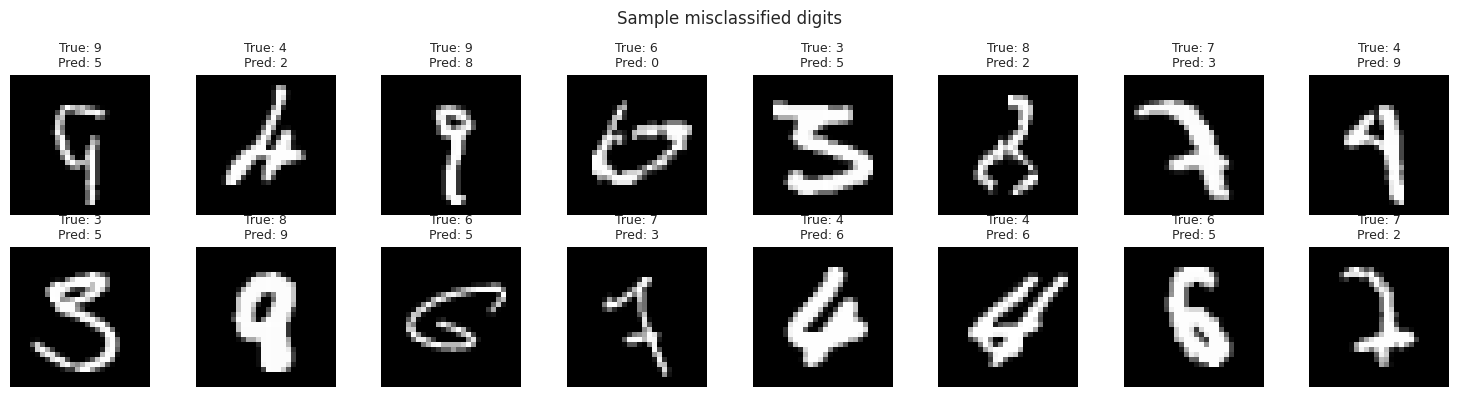

In [15]:
misclassified_idx = np.where(y_test != best_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} of {len(y_test)} ({len(misclassified_idx)/len(y_test):.2%})")

fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for ax, idx in zip(axes.flat, misclassified_idx[:16]):
    ax.imshow(X_test_img[idx], cmap='gray')
    ax.set_title(f"True: {y_test[idx]}\nPred: {best_pred[idx]}", fontsize=9)
    ax.axis('off')
plt.suptitle('Sample misclassified digits')
plt.tight_layout()
plt.show()


Some incorrect predictions are difficult even to distinguish visually because of handwriting style and unusual strokes.

## 7. Challenges Faced

- Dataset access: The project link was not reachable, so the standard MNIST files were loaded from a public mirror and checked before modelling.
- Data format: MNIST is provided in IDX binary files, so a small parser was used to load the images and labels.
- SVM and KNN: Both were trained on a stratified 10,000 image subset to keep training practical on the available CPU.
- Model choice: A dense neural network and CNN were both tested so the benefit of keeping the image structure could be measured rather than assumed.
- Training time: A full XGBoost experiment was tested but was not kept in the final comparison because it took much longer than the other models without being required by the project brief.

## 8. Conclusion

The project compared seven models across classical machine learning and neural networks.

The CNN gave the best result with 98.93% test accuracy and was selected as the recommended model for this dataset. The dense neural network was the next best neural approach at 97.85%, while Random Forest was the strongest classical model at 97.04%.

The confusion matrix and misclassified examples show that most errors occur between visually similar digits.

The project covers the main skills in the problem statement, including computer vision basics, SVM, KNN, neural networks, model comparison and error analysis.